# ReformLab Quickstart — Carbon Tax Impact in Under 15 Minutes

**What is ReformLab?** ReformLab is an OpenFisca-first platform for analyzing environmental policy impacts on households. It handles data, multi-year projections, indicators, and reproducibility — so you can focus on policy design, not infrastructure.

**What you'll learn:**
1. Load a population dataset and understand the adapter pattern
2. Run a carbon tax scenario on synthetic French household data
3. See distributional impacts by income decile
4. Modify the tax rate and compare results
5. Understand how reproducibility is tracked

**Prerequisites:** Just `pip install reformlab` — no data downloads, no API keys, no configuration.

**Time:** 10-15 minutes (reading + execution)

---
## 1. The Data Pipeline — Loading a Population

Every ReformLab simulation starts with **population data**: a table of households with income, carbon emissions, and other attributes. In production you'd use real survey data (e.g., INSEE or EU-SILC). For this quickstart, we ship a pre-generated CSV with 100 synthetic French households.

The key concept is the **adapter pattern**: ReformLab never computes taxes directly. Instead, it passes population data through a *computation adapter* — an interchangeable backend that applies policy formulas. This design means you can swap OpenFisca for a custom engine (or a mock for testing) without changing any orchestration code.

Here's the data flow:

```
CSV file → load into PopulationData → adapter.compute(population, policy, period) → results
```

Let's see it in action.

In [1]:
# Import the public API
from pathlib import Path

from reformlab import (
    RunConfig,
    ScenarioConfig,
    create_quickstart_adapter,
    run_scenario,
    show,
)

print("ReformLab is installed and ready to use!")

ReformLab is installed and ready to use!


### Load the population CSV

The demo population file ships with ReformLab. It contains 100 synthetic households with realistic French income and carbon emission distributions (generated deterministically with `seed=42`).

Let's load it and inspect the first few rows:

In [2]:
# Path to the demo population CSV (shipped with the repo)
POPULATION_PATH = Path("../data/populations/demo-quickstart-100.csv")

# Quick look at the raw data
import pyarrow.csv as pa_csv

population_table = pa_csv.read_csv(POPULATION_PATH)
print(f"Population: {population_table.num_rows} households")
print(f"Columns: {population_table.column_names}")
print()
show(population_table, n=5)

Population: 100 households
Columns: ['household_id', 'income', 'carbon_emissions']

household_id  income              carbon_emissions  
------------  ------------------  ------------------
0             15418.280395373651  2.103133555242056 
1             14341.823812306122  2.15152077652919  
2             16296.33911912492   2.1284878520100574
3             16606.126442056637  2.4453648958053034
4             19613.295798287058  2.2932305747657615
  ... (95 more rows)


### Set up the adapter

The adapter is the bridge between your population data and the computation engine. In production, you'd use an OpenFisca adapter that runs real tax-benefit microsimulation. For this quickstart, `create_quickstart_adapter()` returns a demonstration adapter that applies a simple formula:

```
carbon_tax = carbon_emissions × (rate / baseline_rate)
disposable_income = income - carbon_tax
```

The important thing: **the adapter reads from the population data you loaded**. It doesn't generate fake numbers — it computes results from the actual household incomes and emissions in the CSV.

In [3]:
BASE_RATE = 44.0  # €44/tCO2 — France's 2024 carbon tax rate

adapter = create_quickstart_adapter(
    carbon_tax_rate=BASE_RATE,
    year=2025,
    household_count=population_table.num_rows,
)

print(f"Adapter version: {adapter.version()}")
print(f"Carbon tax rate: €{BASE_RATE}/tCO2")
print("The adapter will compute from the population CSV (not hardcoded data)")

Adapter version: quickstart-demo-v1
Carbon tax rate: €44.0/tCO2
The adapter will compute from the population CSV (not hardcoded data)


---
## 2. Run the Simulation

Now we configure and run the scenario. Notice that `ScenarioConfig` takes a `population_path` — this tells the orchestrator where to load household data from. The adapter receives this population and computes carbon tax impacts for each household.

In [4]:
# Configure the scenario — note population_path points to the CSV we inspected
config = RunConfig(
    scenario=ScenarioConfig(
        template_name="carbon-tax",
        parameters={"rate_schedule": {2025: BASE_RATE}},  # €44/tCO2 in 2025
        population_path=POPULATION_PATH,  # Real data pipeline: CSV → adapter
        start_year=2025,
        end_year=2025,  # Single year for quickstart
    ),
    seed=42,  # For reproducibility
)

print(f"Scenario: {config.scenario.template_name}")
print(f"Carbon tax rate: €{config.scenario.parameters['rate_schedule'][2025]}/tCO2")
print(f"Population: {config.scenario.population_path}")
print(f"Years: {config.scenario.start_year}-{config.scenario.end_year}")
print(f"Seed: {config.seed}")

Scenario: carbon-tax
Carbon tax rate: €44.0/tCO2
Population: ../data/populations/demo-quickstart-100.csv
Years: 2025-2025
Seed: 42


In [5]:
# Run the simulation
# The orchestration pipeline:
# 1. Loads population from the CSV via population_path
# 2. Passes PopulationData to adapter.compute()
# 3. Adapter reads household incomes and emissions, applies carbon tax formula
# 4. Produces panel output (household × year) and run manifest

print("Running simulation...")
result = run_scenario(config, adapter=adapter)
print(result)

Running simulation...
SimulationResult(SUCCESS, scenario='carbon-tax', years=2025-2025, rows=100, manifest='2df56d3d-76fc-4209-ba78-d07b880c5982')


### Inspect the results

The `SimulationResult` contains:
- `panel_output`: A PyArrow table with all computed fields (household × year)
- `manifest`: Provenance metadata (parameters, seeds, data hashes)
- `yearly_states`: State for each completed year

Let's look at a sample of the panel data:

In [6]:
print(f"Panel shape: {result.panel_output.table.num_rows} rows × {result.panel_output.table.num_columns} columns")
print(f"Columns: {result.panel_output.table.column_names}")
print()
show(result.panel_output.table)

Panel shape: 100 rows × 5 columns
Columns: ['household_id', 'year', 'income', 'carbon_tax', 'disposable_income']

household_id  year  income              carbon_tax          disposable_income 
------------  ----  ------------------  ------------------  ------------------
0             2025  15418.280395373651  2.103133555242056   15416.17726181841 
1             2025  14341.823812306122  2.15152077652919    14339.672291529592
2             2025  16296.33911912492   2.1284878520100574  16294.210631272908
3             2025  16606.126442056637  2.4453648958053034  16603.681077160833
4             2025  19613.295798287058  2.2932305747657615  19611.00256771229 
5             2025  18437.015772145955  2.5063350670893842  18434.509437078865
6             2025  19990.705000528666  2.5478793922261485  19988.15712113644 
7             2025  18815.561982532137  2.1582422814672477  18813.40374025067 
8             2025  21389.456514286816  3.0705521203970805  21386.38596216642 
9             202

**What just happened?**
1. The orchestrator loaded the CSV into a `PopulationData` object (a dict of PyArrow tables)
2. The adapter's `compute()` method received the population, read each household's income and emissions, and calculated `carbon_tax` and `disposable_income`
3. The results were assembled into a panel output — one row per household per year

This is the same pipeline that runs with a real OpenFisca adapter in production. The only difference is the computation backend — the orchestration, data loading, and output structure are identical.

**Assumptions:**
- Synthetic French household data (income range ~€14k to ~€98k, emissions 2-14 tCO2/year)
- Carbon tax computed as `emissions × (rate / 44.0)` for the demonstration adapter
- Single-year projection (multi-year in the advanced notebook)

---
## 3. Distributional Analysis — Who Pays the Most?

Carbon taxes are regressive if lower-income households pay a higher share of their income. Let's compute distributional indicators by income decile to see the impact pattern.

ReformLab's indicator system automatically:
- Assigns households to income deciles
- Computes mean, median, sum, min, max for each field
- Groups by decile (and optionally by year)

In [7]:
# Compute distributional indicators
indicators = result.indicators("distributional")

print(f"Computed {len(indicators.indicators)} indicator records")
print(f"Excluded households (no income): {indicators.excluded_count}")
print(f"Warnings: {indicators.warnings if indicators.warnings else 'None'}")

Computed 20 indicator records
Excluded households (no income): 0
Warnings: None


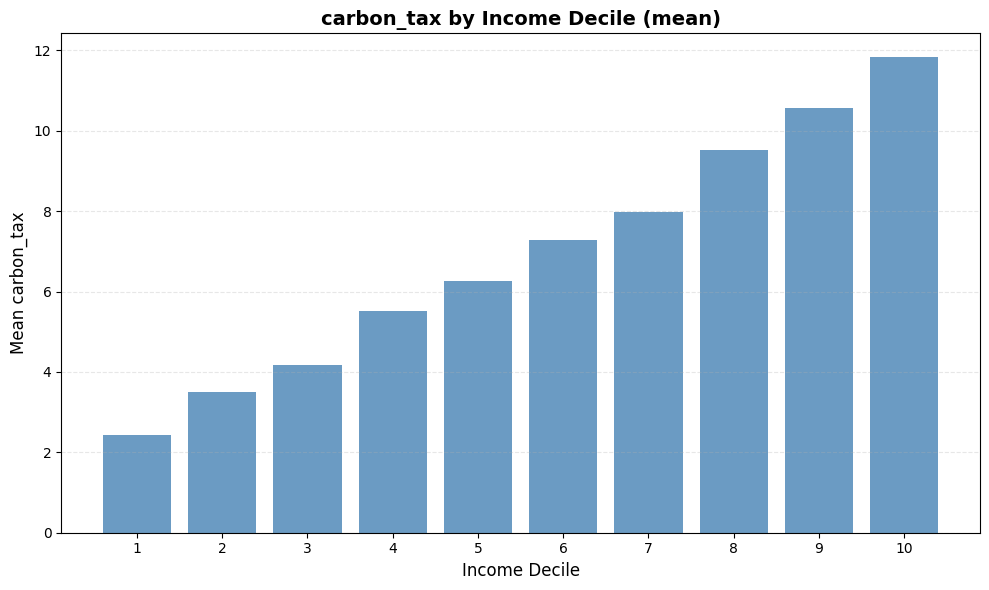


Interpretation:
- If bars increase from left to right: tax burden rises with income (progressive in absolute terms)
- If bars are roughly flat or decrease: tax is regressive (lower-income households pay similar/more)
- To see burden as % of income, compute carbon_tax / income ratios (advanced notebook)


In [8]:
import matplotlib.pyplot as plt

# Plot carbon tax burden by income decile
indicators = result.indicators("distributional")
fig, ax = indicators.plot_deciles("carbon_tax")
plt.show()

print("\nInterpretation:")
print("- If bars increase from left to right: tax burden rises with income (progressive in absolute terms)")
print("- If bars are roughly flat or decrease: tax is regressive (lower-income households pay similar/more)")
print("- To see burden as % of income, compute carbon_tax / income ratios (advanced notebook)")

---
## 4. Parameter Modification — Try It Yourself

Let's see how the distributional impact changes if we **increase the carbon tax rate** from €44/tCO2 to €100/tCO2.

**Exercise:** Modify the rate below and re-run the cells to see updated charts.

In [9]:
# Modify this value and re-run
NEW_RATE = 100.0  # Try 100, 150, or 200

adapter_high = create_quickstart_adapter(
    carbon_tax_rate=NEW_RATE,
    year=2025,
    household_count=population_table.num_rows,
)

# Create and run the new scenario (same population, different rate)
config_high = RunConfig(
    scenario=ScenarioConfig(
        template_name="carbon-tax",
        parameters={"rate_schedule": {2025: NEW_RATE}},
        population_path=POPULATION_PATH,
        start_year=2025,
        end_year=2025,
    ),
    seed=42,
)

print(f"Running with carbon tax rate: €{NEW_RATE}/tCO2...")
result_high = run_scenario(config_high, adapter=adapter_high)
print(result_high)

Running with carbon tax rate: €100.0/tCO2...
SimulationResult(SUCCESS, scenario='carbon-tax', years=2025-2025, rows=100, manifest='c3f67617-37ca-4d4c-985a-9b5fc98393ac')


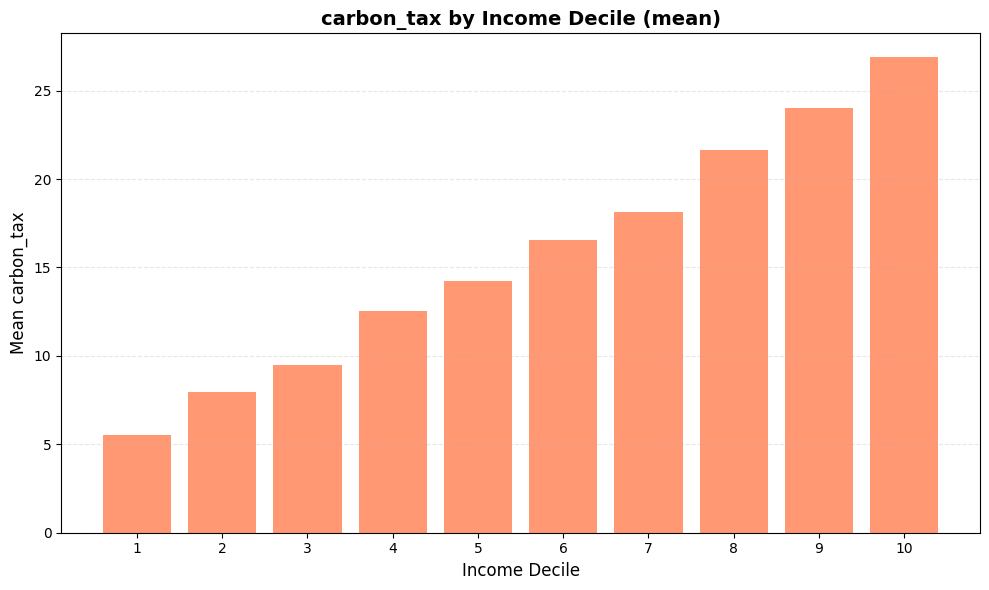


Higher rate (€100.0/tCO2) increases burden proportionally across all deciles.


In [10]:
# Compute indicators for the higher rate and plot
indicators_high = result_high.indicators("distributional")
fig, ax = indicators_high.plot_deciles("carbon_tax", color="coral")
plt.show()

print(f"\nHigher rate (€{NEW_RATE}/tCO2) increases burden proportionally across all deciles.")

---
## 5. Scenario Comparison — Baseline vs. Reform

Let's compare the baseline (€44/tCO2) and reform (higher rate) scenarios side-by-side.

This is a simple visual comparison. For advanced multi-scenario workflows (including multi-year projections and vintage tracking), see the advanced notebook.

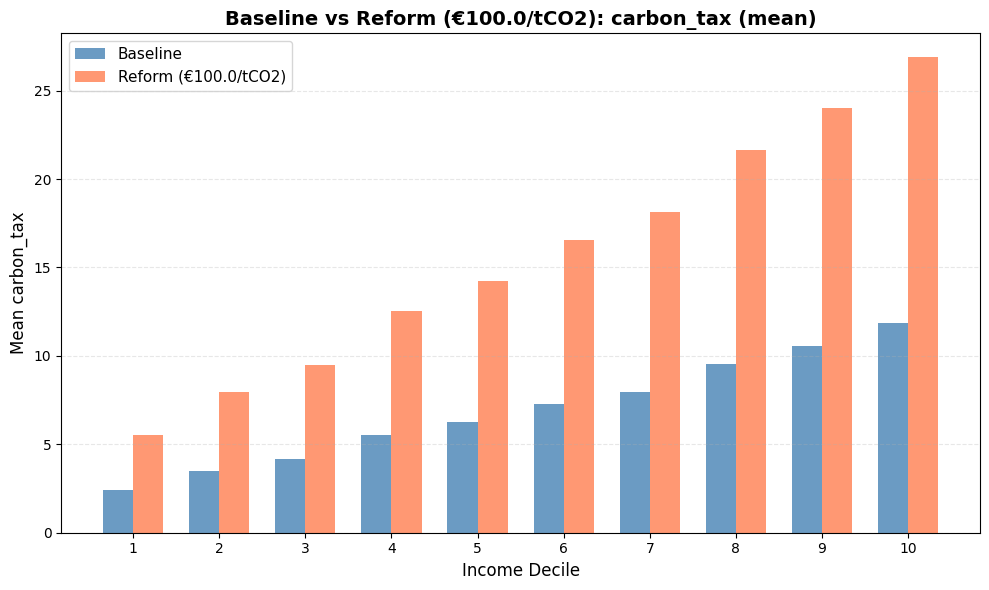


Comparison shows:
- Reform rate increases burden across all deciles
- Pattern of regressivity (or progressivity) remains similar
- For revenue-neutral reforms (tax + rebate), see advanced notebook


In [11]:
# Side-by-side comparison using the built-in plot_comparison method
fig, ax = result.plot_comparison(result_high, "carbon_tax", reform_label=f"Reform (€{NEW_RATE}/tCO2)")
plt.show()

print("\nComparison shows:")
print("- Reform rate increases burden across all deciles")
print("- Pattern of regressivity (or progressivity) remains similar")
print("- For revenue-neutral reforms (tax + rebate), see advanced notebook")

**Scope note:** This quickstart focuses on single-year, single-scenario comparisons. For:
- Multi-year projections with vintage tracking
- Baseline vs. reform with redistribution mechanisms
- Advanced comparison tables and welfare indicators

...see the **advanced notebook** (Story 6-3).

---
## 6. Reproducibility — Understanding the Run Manifest

Every ReformLab simulation produces a **run manifest** — a complete record of:
- Parameters used
- Random seeds
- Data hashes (fingerprints)
- Engine and adapter versions
- Assumptions and mappings

This makes results **reproducible**: anyone can verify they're using the same inputs and code.

In [12]:
# Inspect the manifest
manifest = result.manifest

print("=== Run Manifest ===")
print(f"Manifest ID:      {manifest.manifest_id}")
print(f"Created at:       {manifest.created_at}")
print(f"Engine version:   {manifest.engine_version}")
print(f"Adapter version:  {manifest.adapter_version}")
print(f"Scenario version: {manifest.scenario_version}")
print(f"Parameters:       {manifest.parameters}")
print(f"Seeds:            {manifest.seeds}")
print(f"Warnings:         {manifest.warnings if manifest.warnings else 'None'}")
print(f"Step pipeline:    {manifest.step_pipeline}")

=== Run Manifest ===
Manifest ID:      2df56d3d-76fc-4209-ba78-d07b880c5982
Created at:       2026-03-01T14:05:12.383168+00:00
Engine version:   0.1.0
Adapter version:  quickstart-demo-v1
Scenario version: 1.0.0
Parameters:       {'rate_schedule': {'2025': 44.0}}
Seeds:            {'master': 42}
Warnings:         ["WARNING: Scenario 'carbon-tax' (version 'unknown') is not marked as validated in registry metadata. Action: Mark this scenario as validated before relying on outputs for production decisions."]
Step pipeline:    ['computation']


In [13]:
# The manifest can be exported as JSON in one line
import tempfile, json
from pathlib import Path

manifest_path = result.export_manifest(Path(tempfile.mkdtemp()) / "manifest.json")
print(f"Manifest exported to: {manifest_path}")
print(f"\nManifest contents:")
print(json.dumps(json.loads(manifest_path.read_text()), indent=2))

Manifest exported to: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmp12znk91u/manifest.json

Manifest contents:
{
  "adapter_version": "quickstart-demo-v1",
  "assumptions": [],
  "child_manifests": {
    "2025": "3cdd7b43-7361-46d3-8127-74dd1333f281"
  },
  "created_at": "2026-03-01T14:05:12.383168+00:00",
  "data_hashes": {},
  "engine_version": "0.1.0",
  "integrity_hash": "",
  "manifest_id": "2df56d3d-76fc-4209-ba78-d07b880c5982",
  "mappings": [],
  "openfisca_version": "quickstart-demo-v1",
  "output_hashes": {},
  "parameters": {
    "rate_schedule": {
      "2025": 44.0
    }
  },
  "parent_manifest_id": "2df56d3d-76fc-4209-ba78-d07b880c5982",
  "scenario_version": "1.0.0",
  "seeds": {
    "master": 42
  },
  "step_pipeline": [
    "computation"
  ],
  "warnings": [
    "WARNING: Scenario 'carbon-tax' (version 'unknown') is not marked as validated in registry metadata. Action: Mark this scenario as validated before relying on outputs for production decisions."
  ]
}


**Why does this matter?**
- **Governance**: Policy analysis results must be auditable
- **Reproducibility**: You can rerun the exact same simulation months later
- **Transparency**: Anyone can see what assumptions were made
- **Compliance**: Meets open-data and open-government standards

---
## 7. Export Actions — Save Results for External Analysis

ReformLab provides built-in export functionality to save simulation outputs and indicator results in standard formats (CSV/Parquet). This allows you to:
- Share results with stakeholders
- Import data into external tools (Excel, Tableau, R, etc.)
- Archive outputs for reproducibility

All exports include provenance metadata for traceability.

In [14]:
# Export simulation panel output to CSV
# This saves the complete household × year panel with all computed fields

import tempfile
from pathlib import Path

# Create a temporary directory for exports (use your own path in practice)
export_dir = Path(tempfile.mkdtemp())

# Export panel to CSV
csv_path = result.export_csv(export_dir / "simulation_output.csv")
print(f"Panel exported to CSV: {csv_path}")
print(f"  Size: {csv_path.stat().st_size:,} bytes")

# Export panel to Parquet (more efficient for large datasets)
parquet_path = result.export_parquet(export_dir / "simulation_output.parquet")
print(f"Panel exported to Parquet: {parquet_path}")
print(f"  Size: {parquet_path.stat().st_size:,} bytes")

print(f"\nExported files contain:")
print(f"  - {result.panel_output.table.num_rows} rows (households x years)")
print(f"  - {result.panel_output.table.num_columns} columns")
print(f"  - Fields: {', '.join(result.panel_output.table.column_names)}")

Panel exported to CSV: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpdxpfo6j9/simulation_output.csv
  Size: 6,316 bytes
Panel exported to Parquet: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpdxpfo6j9/simulation_output.parquet
  Size: 5,945 bytes

Exported files contain:
  - 100 rows (households x years)
  - 5 columns
  - Fields: household_id, year, income, carbon_tax, disposable_income


In [15]:
# Export indicator results
# This saves the computed distributional indicators in long-form table format

# Export indicators to CSV
indicators_csv = indicators.export_csv(export_dir / "indicators_distributional.csv")
print(f"Indicators exported to CSV: {indicators_csv}")
print(f"  Size: {indicators_csv.stat().st_size:,} bytes")

# Verify round-trip: reload and check schema
import pyarrow.csv as pa_csv
reloaded = pa_csv.read_csv(indicators_csv)
print(f"\nReloaded CSV verification:")
print(f"  Rows: {reloaded.num_rows}")
print(f"  Columns: {reloaded.column_names}")
print(f"  Sample data:")
show(reloaded, n=5)

Indicators exported to CSV: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpdxpfo6j9/indicators_distributional.csv
  Size: 5,121 bytes

Reloaded CSV verification:
  Rows: 120
  Columns: ['field_name', 'decile', 'year', 'metric', 'value']
  Sample data:
field_name  decile  year  metric  value             
----------  ------  ----  ------  ------------------
carbon_tax  1       None  count   10.0              
carbon_tax  1       None  mean    2.433329643828796 
carbon_tax  1       None  median  2.3692977352855324
carbon_tax  1       None  sum     24.33329643828796 
carbon_tax  1       None  min     2.103133555242056 
  ... (115 more rows)


---
## 8. Next Steps

You've just run a complete carbon tax analysis in under 15 minutes! Here's what to explore next:

### Advanced Notebook (Story 6-3)
- Multi-year projections (2025-2030)
- Vintage tracking (how household composition evolves)
- Revenue-neutral reforms (carbon tax + lump-sum rebate)
- Welfare indicators (winner/loser analysis)
- Advanced scenario comparison workflows with exports

### API Documentation
- `run_scenario()`: Full API reference
- `SimulationResult.indicators()`: All indicator types (distributional, geographic, welfare, fiscal)
- `SimulationResult.export_csv()` / `export_parquet()`: Export panel outputs
- `SimulationResult.export_manifest()`: Export run manifest to JSON
- `IndicatorResult.export_csv()` / `export_parquet()`: Export indicator tables
- Scenario templates: How to create custom policy configurations
- YAML workflows: Define multi-scenario analyses in configuration files

### Custom Scenarios
- Create your own scenario templates
- Combine carbon tax with subsidies/rebates
- Model feebate programs (tax polluters, rebate clean alternatives)

---

**Questions or feedback?** See the project documentation or open an issue on GitHub.